<a href="https://colab.research.google.com/github/BernardoBremer/Inteligencia-Computacional-Cetys-/blob/main/participacion30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment analysis on movie reviews

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [7]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [8]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [9]:
!wget -q https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xzf aclImdb_v1.tar.gz

In [10]:
dataset_root = "aclImdb"

train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

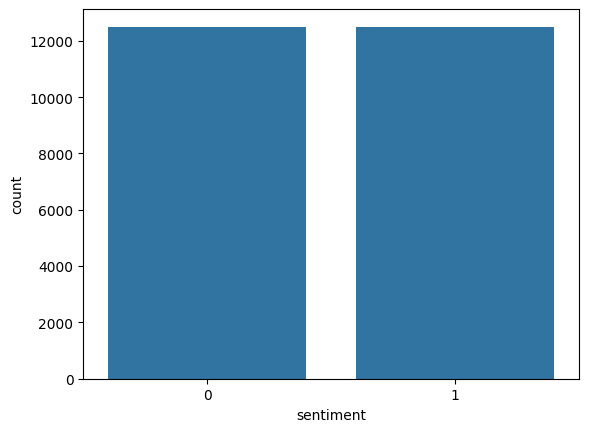

In [11]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [12]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,25000.0,1325.06964,1003.133670,52.0,702.0,979.0,1614.0,13704.0
words,25000.0,233.78720,173.733032,10.0,127.0,174.0,284.0,2470.0
sentiment,25000.0,0.50000,0.500010,0.0,0.0,0.5,1.0,1.0


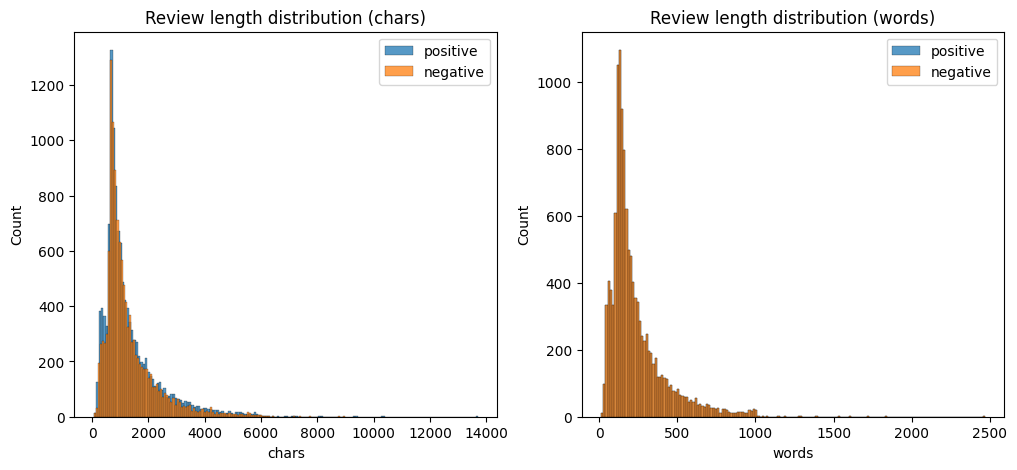

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

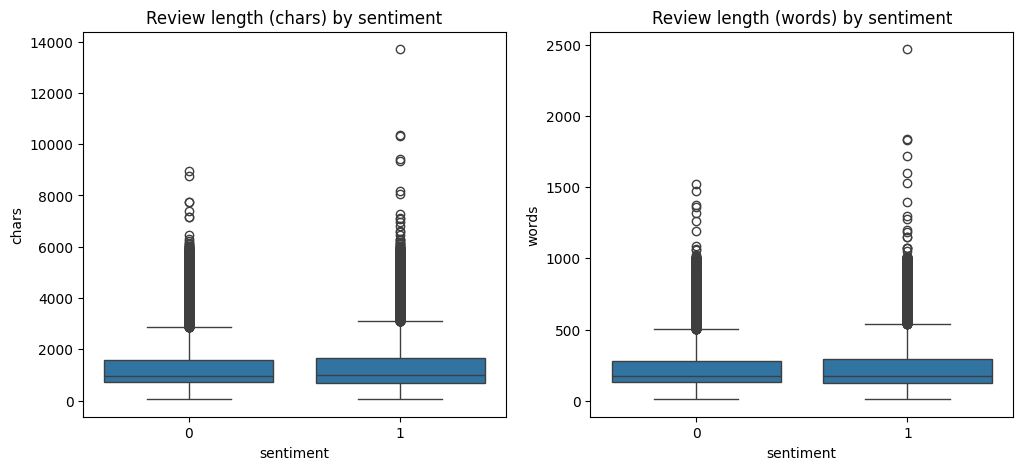

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [16]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [17]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'that', 'I', 'it', 'this', '/><br', 'as', 'with', 'was', 'for', 'The', 'but', 'his', 'on']

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [18]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [19]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'as', 'with', 'for', 'was', 'but', 'film', 'movie', 'his']

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [20]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [22]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [23]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [24]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
['br', 'film', 'movie', 'not', 'one', 'like', 'good', 'story', 'great', 'time', 'see', 'also', 'really', 'would', 'even', 'first', 'much', 'no', 'people', 'films']

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [26]:
print(train_df['review'][0])
print(x_train[0])

Holes is a fable about the past and the way it affects the present lives of at least three people. One of them I will name, the other two are mysteries and will remain so. Holes is a story about Stanley Yelnats IV. He is unlucky in life. Unlucky in fact characterizes the fates of most of the Yelnats men and has been since exploits of Stanley IV's `no good-dirty-rotten-pig-stealing-great-great-grandfather.' Those particular exploits cursed the family's men to many an ill-fated turn. It is during just such a turn that we meet Stanley IV. He has been accused, falsely, of stealing a pair of baseball shoes, freshly donated to a homeless shelter auction, by a famous baseball player. He is given the option of jail, or he can go to a character building camp. `I've never been to camp before,' says Stanley. With that the Judge enthusiastically sends him off to Camp Green Lake.<br /><br />Camp Green Lake is an odd place, with an odd philosophy, `If you take a bad boy, make him dig a hole every da

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [27]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(39, 1), (1503, 1), (1661, 1), (1821, 1), (2022, 1), (2025, 1), (2035, 1), (2150, 1), (2742, 1), (2776, 1), (2815, 1), (3385, 1), (3529, 2), (3705, 1), (4889, 1), (4929, 1), (5066, 1), (5239, 1), (5489, 1), (5933, 1), (6102, 2), (6470, 1), (6700, 1), (6702, 1), (7481, 2), (7609, 1), (8680, 2), (8693, 3), (8703, 6), (9538, 1), (9609, 1), (10291, 8), (10466, 1), (10558, 2), (10665, 1), (11591, 2), (11608, 1), (11630, 1), (11758, 1), (13474, 1), (13695, 1), (14593, 1), (14790, 1), (15047, 1), (15058, 1), (15059, 1), (15756, 1), (16040, 1), (16041, 1), (16430, 2), (16506, 1), (16673, 1), (16756, 1), (16905, 1), (17035, 1), (17776, 1), (17942, 1), (18311, 1), (18337, 1), (18580, 2), (19396, 1), (19543, 1), (20224, 1), (20533, 1), (21373, 2), (21891, 1), (22029, 1), (22041, 1), (22052, 1), (22729, 1), (22736, 1), (22739, 1), (23189, 3), (23435, 1), (23484, 2), (23622, 1), (23659, 5), (23666, 1), (23907, 1), (23911, 1), (23913, 1), (23954, 1), (24100, 2), (24445, 1), (24491, 1), (24504, 4), 

The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [28]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

10: 1
accused: 1
acts: 1
admiration: 1
affect: 1
affected: 1
affects: 1
age: 1
ally: 1
along: 1
also: 1
angsty: 1
another: 2
anyone: 1
attitude: 1
auction: 1
authority: 1
away: 1
bad: 1
barbs: 1
baseball: 2
becomes: 1
believable: 1
believe: 1
bitter: 2
blake: 1
boy: 2
boys: 3
br: 6
building: 1
bully: 1
camp: 8
capacity: 1
captures: 2
caring: 1
character: 2
characterizes: 1
charges: 1
cheap: 1
comedy: 1
compelling: 1
conventional: 1
core: 1
councilor: 1
counselor: 1
counselors: 1
cruel: 1
curse: 1
cursed: 1
dangerous: 2
dares: 1
day: 1
deals: 1
decided: 1
deep: 1
desert: 1
determined: 1
different: 1
dig: 1
dirty: 2
doesn: 1
donated: 1
dry: 1
dusty: 1
else: 2
enjoy: 1
entertains: 1
enthusiastically: 1
entirely: 1
every: 1
everyone: 1
everything: 1
exploits: 3
fable: 1
fact: 2
falsely: 1
family: 5
famous: 1
fated: 1
fates: 1
father: 1
fauna: 1
feet: 2
fight: 1
filled: 1
film: 4
five: 2
freshly: 1
genera: 1
get: 1
give: 1
given: 1
go: 1
good: 5
grandfather: 3
great: 4
green: 5
guidance: 1


One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [30]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 I love Monte Carlo and thoroughly enjoyed this movie. I thought everyone was very good. I was not familiar with Richard Lewis, I thought he made his character (Julian Peters) very personable, funny and attractive. Sean Young was very good as the befuddled rejected girl with a heart of gold. George Hamilton was charming and the perfect Italian gigolo. John Candy has a field day as the bon vivant. James Belushi is hysterical as a total jerk. Cybill Shepard gave a very sweet performance as a nice vulnerable ignored housewife. Delightful ensemble cast. Lots of talent, clever script, lots going on and beautiful locations. Just a nice pick me up for a dreary day. Especially in the winter when a trip to Europe is not anywhere on your horizon.

Original review (no stopwords):
 love Monte Carlo thoroughly enjoyed movie. thought everyone good. not familiar Richard Lewis, thought made character (Julian Peters) personable, funny attractive. Sean Young good befuddled rejected girl

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [32]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [33]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df


,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99896,0.86528,0.999040,0.871220,0.99888,0.85728,0.998960,0.864194
0,CountVectorizer,0.99832,0.86360,0.998480,0.869813,0.99816,0.85520,0.998320,0.862445


The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [34]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.196),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

In [38]:
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_stem(text):
    text = normalize_text(text)
    return " ".join([stemmer.stem(w) for w in text.split()])

def preprocess_lemma(text):
    text = normalize_text(text)
    return " ".join([lemmatizer.lemmatize(w) for w in text.split()])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [42]:
train_exp_df = train_exp_df.sample(n=5000, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_exp_df.sample(n=5000, random_state=RANDOM_STATE).reset_index(drop=True)


train_stem = train_exp_df["review"].apply(preprocess_stem)
train_lemma = train_exp_df["review"].apply(preprocess_lemma)
test_stem = test_exp_df["review"].apply(preprocess_stem)
test_lemma = test_exp_df["review"].apply(preprocess_lemma)
print("Done")

Done


In [43]:
def run_experiment_precached(vectorizer, train_text, test_text):
    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df["sentiment"]
    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df["sentiment"]

    model = LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        "accuracy_train": accuracy_score(y_train, y_train_pred),
        "accuracy_test": accuracy_score(y_test, y_test_pred),
        "precision_train": precision_score(y_train, y_train_pred),
        "precision_test": precision_score(y_test, y_test_pred),
        "recall_train": recall_score(y_train, y_train_pred),
        "recall_test": recall_score(y_test, y_test_pred),
        "f1_train": f1_score(y_train, y_train_pred),
        "f1_test": f1_score(y_test, y_test_pred),
    }
    return model, vectorizer, metrics

experiments_new = [
    ("CountVectorizer-stem", train_stem, test_stem, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ("CountVectorizer-lemma", train_lemma, test_lemma, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ("TfidfVectorizer-stem", train_stem, test_stem, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ("TfidfVectorizer-lemma", train_lemma, test_lemma, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results_new = []
model_runs_new = []
for exp_name, tr_text, te_text, vectorizer in experiments_new:
    model, fitted_vectorizer, metrics = run_experiment_precached(vectorizer, tr_text, te_text)
    results_new.append({"vectorizer": exp_name, **metrics})
    model_runs_new.append({"name": exp_name, "model": model, "fitted_vectorizer": fitted_vectorizer})

results_new_df = pd.DataFrame(results_new).sort_values("accuracy_test", ascending=False)
results_new_df

,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
3,TfidfVectorizer-lemma,0.9534,0.8544,0.949045,0.849266,0.957814,0.860185,0.953409,0.854691
2,TfidfVectorizer-stem,0.9444,0.8478,0.937475,0.843402,0.951788,0.852551,0.944577,0.847952
1,CountVectorizer-lemma,1.0000,0.8368,1.000000,0.831813,1.000000,0.842507,1.000000,0.837126
0,CountVectorizer-stem,1.0000,0.8320,1.000000,0.826793,1.000000,0.838088,1.000000,0.832402


In [44]:
print("Top 10 positive words across new experiments")
print_compact_feature_table(model_runs_new, sentiment="positive", top_n=10)

print("Top 10 negative words across new experiments")
print_compact_feature_table(model_runs_new, sentiment="negative", top_n=10)

Top 10 positive words across new experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,excel (1.341),favorite (1.300),great (4.745),great (4.813)
#2,favorit (1.249),excellent (1.174),excel (3.491),excellent (3.274)
#3,brilliant (0.998),perfect (1.013),love (3.211),best (3.002)
#4,perfect (0.919),brilliant (1.001),best (2.893),well (2.845)
#5,masterpiec (0.902),great (0.907),well (2.753),love (2.711)
#6,great (0.863),amazing (0.888),favorit (2.326),favorite (2.392)
#7,definit (0.837),definitely (0.880),enjoy (2.318),wonderful (2.208)
#8,delight (0.827),liked (0.845),beauti (2.191),life (2.193)
#9,unexpect (0.818),highly (0.839),perfect (2.102),ha (2.062)


Top 10 negative words across new experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,worst (-1.834),worst (-1.831),bad (-5.375),bad (-5.500)
#2,wast (-1.663),waste (-1.802),worst (-4.314),worst (-4.459)
#3,bore (-1.587),boring (-1.499),wast (-3.852),no (-3.741)
#4,aw (-1.514),awful (-1.394),no (-3.601),waste (-3.392)
#5,poor (-1.316),save (-1.289),bore (-3.451),boring (-3.004)
#6,bad (-1.072),poor (-1.211),aw (-3.025),poor (-2.934)
#7,pointless (-1.063),bad (-1.124),poor (-2.942),awful (-2.913)
#8,save (-1.045),avoid (-1.124),noth (-2.787),nothing (-2.841)
#9,terribl (-1.026),basically (-1.110),terribl (-2.770),terrible (-2.824)


#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?

La combinacion que da mejor rendimiento es tfidfVectorizer con lemmatization, porque TF-IDF penaliza las palabras que aparecen en muchos documentos, lo cual ayuda a que el modelo se enfoque en palabras mas informativas. La lematizacion agrupa variantes de una misma palabra por ejemplo movies y movie se convierten en  movie, lo que reduse el vocabulario sin perder tanta informacion semantica como el stemming.

En cuanto a las top features, se puede ver que con stemming las raices de las palbras a veces pierden su significado original. lo que puede confundir la interpretacion. Con lemmatization las palabras mantienen su forma legible.

#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

In [47]:
best_run = model_runs_new[0]

my_review = """I recently watched Dune Part Two and it was an absolutely incredible experience.
The visuals were stunning and the soundtrack by Hans Zimmer was phenomenal. Timothee Chalamet
delivered a powerful performance as Paul Atreides and the story kept me on the edge of my seat
the entire time. The action scenes were breathtaking and the world building was impressive.
Some parts in the middle felt a little slow but overall it was one of the best sci fi movies
I have seen in years. Highly recommended."""

my_review_vec = best_run["fitted_vectorizer"].transform([my_review])
prediction = best_run["model"].predict(my_review_vec)
proba = best_run["model"].predict_proba(my_review_vec)

print(f"Review: {my_review}")
print(f"Prediction: {"positive" if prediction[0] == 1 else "negative"}")
print(f"Probability: {proba[0]}")

Review: I recently watched Dune Part Two and it was an absolutely incredible experience. 
The visuals were stunning and the soundtrack by Hans Zimmer was phenomenal. Timothee Chalamet 
delivered a powerful performance as Paul Atreides and the story kept me on the edge of my seat 
the entire time. The action scenes were breathtaking and the world building was impressive. 
Some parts in the middle felt a little slow but overall it was one of the best sci fi movies 
I have seen in years. Highly recommended.
Prediction: positive
Probability: [0.03821528 0.96178472]


El modelo predice que mi reseña es positiva, lo cual es correcto. Mi review contiene muchas palabras asociadas con sentimiento positivo como "incredible", "stunning", "phenomenal", "powerful", "breathtaking" y "recommended". Aunque algunas partes fueron lentas, el tono general de la reseña es claramente positivo, asi que estoy de acuerdo con la prediccion del modelo.

#### Write your final remarks on this activity.

pude ver como distintas tecnicas de preprocesamiento y vectorizacion afectan el rendimiento de un modelo de clasificacion de sentimientos. aprendi que TF-IDF generalmente funciona mejor que CountVectorizer porque le da menor peso a palabras muy comunes que no aportan informacion util para distinguir sentimeintos. Tambien vi que lemmatization es preferible al stemming porque mantiene las palabras en una forma legible y no pierde tanta informacion.



###uso de AI
le pedi a ia que me diera un review ya que tengo meses sin ver una peli y la verdad la creatividad en la noche ya no me daba.